# Forward Jet MET Performance

Notebook version of `met_forward_jet_performance.py`. It scans ROOT ntuples, finds forward jets used in MET, and writes a ROOT histogram of their transverse momentum.

In [222]:
import os
import glob
import math
from pathlib import Path
from typing import List, Optional

import ROOT
import numpy as np

from rdf_analysis.stats.histograms import get_bins, get_bins_log
from rdf_analysis.analyses.met_inputs_common import (
    METConfig,
    TransverseVector,
    build_clusters,
    build_leptons,
    build_met_inputs,
    build_truth_met,
)
from rdf_analysis.core import NtupleProcessor, awkward_to_numpy
from rdf_analysis.stats import make_hist_from_bin_contents

ROOT.gROOT.SetBatch(True)
GEV = METConfig.GEV


In [223]:
def dr(eta1, phi1, eta2, phi2):
    dphi = math.atan2(math.sin(phi1 - phi2), math.cos(phi1 - phi2))
    return math.hypot(eta1 - eta2, dphi)


def input_files(input_files: Optional[List[str]] = None, input_dir: Optional[str] = None) -> List[str]:
    """Resolve explicit and recursively discovered input ROOT files."""
    resolved = []
    for item in list(input_files or []):
        matches = glob.glob(item)
        resolved.extend(matches if matches else [item])
    if input_dir:
        for root, _, files in os.walk(input_dir):
            resolved.extend(
                os.path.join(root, name)
                for name in files
                if name.endswith(".root")
            )
    resolved = sorted(set(resolved))
    if not resolved:
        raise ValueError("Provide at least one input file or input directory.")
    return resolved


In [224]:
INPUT_FILES = "/mnt/data2/HEP/Data/Project-W-Z/MiniTreeMaker_Outputs/wmunu_phpy8_v230826_forMETStudy/*/outTree.root"  # Example: ["/path/to/file.root"]
INPUT_DIR = None  # Example: "/path/to/root/files"
TREE = "treeAnaWZ"
N_EVENTS = 500000  # Negative means all events
CHUNK_STEP_SIZE = "25 MB"  # Lower this if one chunk still gets too large.
SAMPLE_EVENTS = 1000  # Small preview only; full processing uses chunks below.
OUTPUT = "output.root"

FORWARD_ETA_MIN = 2.5
FORWARD_ETA_MAX = 4.9

columns = [
    "mu_pt", "mu_eta", "mu_phi", "tboson_pt", "tboson_eta", "tboson_phi",
    "tu_pt.second", "tu_phi.second", "avgMu", "nPrimVtx",
    "met_input_el_pt", "met_input_el_phi", "met_input_el_weight",
    "met_input_mu_pt", "met_input_mu_phi", "met_input_mu_weight",
    "met_input_jet_pt", "met_input_jet_eta", "met_input_jet_phi", "met_input_jet_weight",
    "met_softtrk_mpx", "met_softtrk_mpy",
    "fClusterEta", "fClusterPhi", "fCluster_rawE", "fCluster_calE",
    "fCluster_MLE", "cluster_e_ML_forward", "fCluster_truthE",
    "jet_pt", "jet_eta", "jet_phi", "jet_cluster_truthE", "jet_cluster_MLE", "jet_cluster_rawE",
    "jet_pileup_pt", "jet_pileup_e",
    "tjet_pt", "tjet_eta", "tjet_phi", "tjet_e",
]


In [225]:
import uproot
import awkward as ak

input_patterns = [INPUT_FILES] if isinstance(INPUT_FILES, str) else INPUT_FILES
INPUT_PATHS = input_files(input_patterns, INPUT_DIR)
print(f"matched {len(INPUT_PATHS)} input files")

# Keep one opened tree for inspection, e.g. tree.show().
file = uproot.open(INPUT_PATHS[0])
tree = file[TREE]

matched 754 input files


In [226]:
# Preview array for the exploratory cells below. Do not use this for large samples.
preview_events = SAMPLE_EVENTS if N_EVENTS < 0 else min(SAMPLE_EVENTS, N_EVENTS)
arrays = uproot.concatenate(
    [f"{path}:{TREE}" for path in INPUT_PATHS],
    columns,
    library="ak",
    entry_stop=preview_events,
)
len(arrays["met_input_jet_pt"])


1000

In [227]:
#tree.show()

In [228]:
import awkward as ak
# make zip of few properties which i will be using in analysis
features = ak.zip({
    "mu_pt": arrays["mu_pt"],
    "met_jet_pt": arrays["met_input_jet_pt"],
    "jet_pt": arrays["jet_pt"],
    "jet_eta": arrays["jet_eta"],
    "jet_phi": arrays["jet_phi"],
    "jet_pileup_pt": arrays["jet_pileup_pt"],
    "jet_pileup_e": arrays["jet_pileup_e"],
    "tjet_pt": arrays["tjet_pt"],
    "tjet_eta": arrays["tjet_eta"],
    "tjet_phi": arrays["tjet_phi"],
    "fClusterEta": arrays["fClusterEta"],
    "fClusterPhi": arrays["fClusterPhi"],
    "fCluster_rawE": arrays["fCluster_rawE"],
    "fCluster_MLE": arrays["fCluster_MLE"],
    "fCluster_truthE": arrays["fCluster_truthE"],
    "cluster_e_ML_forward": arrays["cluster_e_ML_forward"],
    }
    ,depth_limit=1
)

## Columnar ΔR matching

The grouped `jet_cluster_*` branches are empty in this sample, so match the global `fCluster*` collection to MET-selected forward jets manually with Awkward arrays. This keeps the layout columnar: event → forward MET-matched jet → matched clusters.

In [229]:
JET_R = 0.4
MET_JET_MATCH_DR = 1e-3

CLUSTER_ENERGY_BRANCHES = {
    "raw": "fCluster_rawE",
    "cal": "fCluster_calE",
    "ml": "fCluster_MLE",
    "ml_forward": "cluster_e_ML_forward",
    "truth": "fCluster_truthE",
}

CLUSTER_ENERGY_UNITS = {
    "raw": GEV,
    "cal": GEV,
    "ml": GEV,
    "ml_forward": 1.0,
    "truth": GEV,
}


def delta_phi(phi1, phi2):
    return np.arctan2(np.sin(phi1 - phi2), np.cos(phi1 - phi2))


In [230]:
# Reco jets, MET input jets, and global topoclusters as jagged records.
jets = ak.zip({
    "idx": ak.local_index(arrays["jet_pt"]),
    "pt": arrays["jet_pt"] * GEV,
    "eta": arrays["jet_eta"],
    "phi": arrays["jet_phi"],
})

met_jets = ak.zip({
    "idx": ak.local_index(arrays["met_input_jet_pt"]),
    "pt": arrays["met_input_jet_pt"] * GEV,
    "eta": arrays["met_input_jet_eta"],
    "phi": arrays["met_input_jet_phi"],
    "weight": arrays["met_input_jet_weight"],
})

cluster_energy_scale = "ml"
cluster_energy = arrays[CLUSTER_ENERGY_BRANCHES[cluster_energy_scale]] * CLUSTER_ENERGY_UNITS[cluster_energy_scale]

clusters = ak.zip({
    "idx": ak.local_index(arrays["fClusterEta"]),
    "eta": arrays["fClusterEta"],
    "phi": arrays["fClusterPhi"],
    "energy": cluster_energy,
    "pt": cluster_energy / np.cosh(arrays["fClusterEta"]),
})



In [231]:
# Chunked processing for large samples: no full-sample `arrays` or cartesian products in RAM.
CHUNK_COLUMNS = [
    "met_input_jet_pt", "met_input_jet_eta", "met_input_jet_phi", "met_input_jet_weight",
    "fClusterEta", "fClusterPhi", "fCluster_rawE", "fCluster_calE",
    "fCluster_truthE", "cluster_e_ML_forward",
    "tjet_pt", "tjet_eta", "tjet_phi",
]

CHUNK_CLUSTER_PT_RECO_SCALES = {
    "rawE": ("fCluster_rawE", GEV),
    "truthE": ("fCluster_truthE", GEV),
    "calE": ("fCluster_calE", GEV),
    "forward_e_ML": ("cluster_e_ML_forward", 1.0),
}


def finite_flatten(values):
    flat = ak.to_numpy(ak.flatten(values, axis=None))
    return flat[np.isfinite(flat)]


def append_finite(target, values):
    flat = finite_flatten(values)
    if flat.size:
        target.append(flat)


def concat_or_empty(parts):
    return np.concatenate(parts) if parts else np.array([], dtype=np.float64)


chunk_accumulators = {
    "forward_jet_pt": [],
    "matched_truth_pt": [],
    "matched_truth_dr": [],
    "cluster_pt": {scale: [] for scale in CHUNK_CLUSTER_PT_RECO_SCALES},
    "response": {"MET jet / truth": []},
}
for scale in CHUNK_CLUSTER_PT_RECO_SCALES:
    chunk_accumulators["response"][f"Σ cluster pT ({scale}) / truth"] = []

processed_events = 0
for chunk in uproot.iterate(
    [f"{path}:{TREE}" for path in INPUT_PATHS],
    CHUNK_COLUMNS,
    library="ak",
    step_size=CHUNK_STEP_SIZE,
):
    chunk_events = len(chunk["met_input_jet_pt"])
    if N_EVENTS >= 0:
        remaining_events = N_EVENTS - processed_events
        if remaining_events <= 0:
            break
        if chunk_events > remaining_events:
            chunk = chunk[:remaining_events]
            chunk_events = remaining_events
    processed_events += chunk_events

    chunk_met_jets = ak.zip({
        "idx": ak.local_index(chunk["met_input_jet_pt"]),
        "pt": chunk["met_input_jet_pt"] * GEV,
        "eta": chunk["met_input_jet_eta"],
        "phi": chunk["met_input_jet_phi"],
        "weight": chunk["met_input_jet_weight"],
    })
    chunk_forward_met_jets = chunk_met_jets[
        np.isfinite(chunk_met_jets.pt)
        & np.isfinite(chunk_met_jets.eta)
        & np.isfinite(chunk_met_jets.phi)
        & (np.abs(chunk_met_jets.eta) >= FORWARD_ETA_MIN)
        & (np.abs(chunk_met_jets.eta) < FORWARD_ETA_MAX)
    ]
    append_finite(chunk_accumulators["forward_jet_pt"], chunk_forward_met_jets.pt)

    cluster_fields = {
        "eta": chunk["fClusterEta"],
        "phi": chunk["fClusterPhi"],
    }
    cluster_pt_field_by_scale = {}
    for scale_name, (energy_branch, unit) in CHUNK_CLUSTER_PT_RECO_SCALES.items():
        pt_field = f"pt_{scale_name}"
        cluster_pt_field_by_scale[scale_name] = pt_field
        cluster_energy = chunk[energy_branch] * unit
        cluster_fields[pt_field] = cluster_energy / np.cosh(chunk["fClusterEta"])

    chunk_clusters = ak.zip(cluster_fields)
    chunk_cluster_pairs = ak.cartesian(
        {"jet": chunk_forward_met_jets, "cluster": chunk_clusters},
        nested=True,
    )
    chunk_cluster_dr = np.sqrt(
        (chunk_cluster_pairs.cluster.eta - chunk_cluster_pairs.jet.eta) ** 2
        + delta_phi(chunk_cluster_pairs.cluster.phi, chunk_cluster_pairs.jet.phi) ** 2
    )
    chunk_matched_cluster_pairs = chunk_cluster_pairs[chunk_cluster_dr < JET_R]
    chunk_cluster_pt_by_scale = {
        scale_name: ak.sum(chunk_matched_cluster_pairs.cluster[pt_field], axis=-1)
        for scale_name, pt_field in cluster_pt_field_by_scale.items()
    }
    for scale_name, cluster_pt in chunk_cluster_pt_by_scale.items():
        append_finite(chunk_accumulators["cluster_pt"][scale_name], cluster_pt)

    chunk_truth_jets = ak.zip({
        "idx": ak.local_index(chunk["tjet_pt"]),
        "pt": chunk["tjet_pt"] * GEV,
        "eta": chunk["tjet_eta"],
        "phi": chunk["tjet_phi"],
    })
    chunk_truth_pairs = ak.cartesian(
        {"jet": chunk_forward_met_jets, "truth": chunk_truth_jets},
        nested=True,
    )
    chunk_truth_dr = np.sqrt(
        (chunk_truth_pairs.truth.eta - chunk_truth_pairs.jet.eta) ** 2
        + delta_phi(chunk_truth_pairs.truth.phi, chunk_truth_pairs.jet.phi) ** 2
    )
    chunk_truth_pairs = ak.with_field(chunk_truth_pairs, chunk_truth_dr, "dr")
    chunk_truth_matches = chunk_truth_pairs[chunk_truth_dr < JET_R]
    nearest_chunk_truth_matches = ak.firsts(
        chunk_truth_matches[ak.argsort(chunk_truth_matches.dr, axis=-1)],
        axis=-1,
    )
    chunk_matched_truth_pt = ak.fill_none(nearest_chunk_truth_matches.truth.pt, np.nan)
    chunk_matched_truth_dr = ak.fill_none(nearest_chunk_truth_matches.dr, np.nan)
    append_finite(chunk_accumulators["matched_truth_pt"], chunk_matched_truth_pt)
    append_finite(chunk_accumulators["matched_truth_dr"], chunk_matched_truth_dr)

    valid_truth_pt = np.isfinite(chunk_matched_truth_pt) & (chunk_matched_truth_pt > 0.0)
    append_finite(
        chunk_accumulators["response"]["MET jet / truth"],
        ak.where(valid_truth_pt, chunk_forward_met_jets.pt / chunk_matched_truth_pt, np.nan),
    )
    for scale_name, cluster_pt in chunk_cluster_pt_by_scale.items():
        append_finite(
            chunk_accumulators["response"][f"Σ cluster pT ({scale_name}) / truth"],
            ak.where(valid_truth_pt, cluster_pt / chunk_matched_truth_pt, np.nan),
        )

    if processed_events % 10000 < chunk_events:
        print(f"processed {processed_events} events")

forward_jet_pt_values_chunked = concat_or_empty(chunk_accumulators["forward_jet_pt"])
matched_truth_jet_pt_values_chunked = concat_or_empty(chunk_accumulators["matched_truth_pt"])
matched_truth_jet_dr_values_chunked = concat_or_empty(chunk_accumulators["matched_truth_dr"])
cluster_reco_pt_values_chunked = {
    scale: concat_or_empty(parts)
    for scale, parts in chunk_accumulators["cluster_pt"].items()
}
response_values_chunked = {
    label: concat_or_empty(parts)
    for label, parts in chunk_accumulators["response"].items()
}

print(f"processed events: {processed_events}")
print(f"forward MET jets: {forward_jet_pt_values_chunked.size}")
print(f"truth matched jets: {matched_truth_jet_pt_values_chunked.size}")


processed 10969 events
processed 20940 events
processed 30903 events
processed 40862 events
processed 50825 events
processed 60787 events
processed 70757 events
processed 80726 events
processed 90694 events
processed 100657 events
processed 110628 events
processed 120595 events
processed 130558 events
processed 140526 events
processed 150490 events
processed 160460 events
processed 170429 events
processed 180390 events
processed 190363 events
processed 200332 events
processed 210293 events
processed 220262 events
processed 230231 events
processed 240201 events
processed 250175 events
processed 260131 events
processed 270100 events
processed 280061 events
processed 290026 events
processed 300990 events
processed 310959 events
processed 320930 events
processed 330897 events
processed 340864 events
processed 350728 events
processed 360692 events
processed 370658 events
processed 380619 events
processed 390589 events
processed 400542 events
processed 410510 events
processed 420474 events
p

In [232]:
# Find cluster energy inside ΔR < 0.4 around each forward MET jet.
forward_met_jets = met_jets[
    np.isfinite(met_jets.pt)
    & np.isfinite(met_jets.eta)
    & np.isfinite(met_jets.phi)
    & (np.abs(met_jets.eta) >= 2.5)
    & (np.abs(met_jets.eta) < 4.9)
]

jet_cluster_pairs = ak.cartesian(
    {"jet": forward_met_jets, "cluster": clusters},
    nested=True,
)
cluster_jet_dr = np.sqrt(
    (jet_cluster_pairs.cluster.eta - jet_cluster_pairs.jet.eta) ** 2
    + delta_phi(jet_cluster_pairs.cluster.phi, jet_cluster_pairs.jet.phi) ** 2
)
matched_pairs = jet_cluster_pairs[cluster_jet_dr < JET_R]
print(matched_pairs)



[[[{jet: {idx: 2, pt: 47.2, ...}, cluster: {...}}, ..., {jet: ..., ...}]], ...]


In [233]:
cluster_energy_in_jet = ak.sum(matched_pairs.cluster.energy, axis=-1)
cluster_pt_in_jet = ak.sum(matched_pairs.cluster.pt, axis=-1)
n_clusters_in_jet = ak.num(matched_pairs.cluster.energy, axis=-1)

forward_met_jets_with_clusters = ak.with_field(
    forward_met_jets,
    cluster_energy_in_jet,
    f"cluster_energy_{cluster_energy_scale}",
)
forward_met_jets_with_clusters = ak.with_field(
    forward_met_jets_with_clusters,
    cluster_pt_in_jet,
    f"cluster_pt_{cluster_energy_scale}",
)
forward_met_jets_with_clusters = ak.with_field(
    forward_met_jets_with_clusters,
    n_clusters_in_jet,
    "n_clusters",
)

print(f"forward MET jets: {ak.sum(ak.num(forward_met_jets))}")
print(f"matched clusters: {ak.sum(ak.flatten(n_clusters_in_jet, axis=None))}")
ak.flatten(forward_met_jets_with_clusters, axis=1)[:10]

forward MET jets: 126
matched clusters: 587


<Array [{idx: 2, pt: 47.2, eta: ..., ...}, ...] type='10 * {idx: int64, pt:...'>

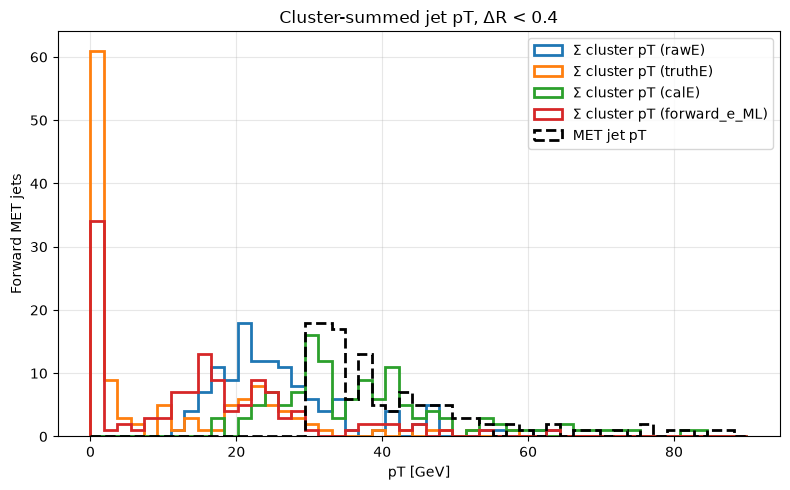

forward MET jets: 126
rawE: entries=126, mean=26.55 GeV
truthE: entries=126, mean=10.67 GeV
calE: entries=126, mean=38.02 GeV
forward_e_ML: entries=126, mean=15.96 GeV


In [234]:
import matplotlib.pyplot as plt

CLUSTER_PT_RECO_SCALES = {
    "rawE": ("fCluster_rawE", GEV),
    "truthE": ("fCluster_truthE", GEV),
    "calE": ("fCluster_calE", GEV),
    "forward_e_ML": ("cluster_e_ML_forward", 1.0),
}

forward_met_jets = met_jets[
    np.isfinite(met_jets.pt)
    & np.isfinite(met_jets.eta)
    & np.isfinite(met_jets.phi)
    & (np.abs(met_jets.eta) >= FORWARD_ETA_MIN)
    & (np.abs(met_jets.eta) < FORWARD_ETA_MAX)
]


def finite_flatten(values):
    flat = ak.to_numpy(ak.flatten(values, axis=None))
    return flat[np.isfinite(flat)]


cluster_fields = {
    "eta": arrays["fClusterEta"],
    "phi": arrays["fClusterPhi"],
}
cluster_pt_field_by_scale = {}
for scale_name, (energy_branch, unit) in CLUSTER_PT_RECO_SCALES.items():
    pt_field = f"pt_{scale_name}"
    cluster_pt_field_by_scale[scale_name] = pt_field
    cluster_energy = arrays[energy_branch] * unit
    cluster_fields[pt_field] = cluster_energy / np.cosh(arrays["fClusterEta"])

multi_scale_clusters = ak.zip(cluster_fields)
multi_scale_pairs = ak.cartesian(
    {"jet": forward_met_jets, "cluster": multi_scale_clusters},
    nested=True,
)
multi_scale_dr = np.sqrt(
    (multi_scale_pairs.cluster.eta - multi_scale_pairs.jet.eta) ** 2
    + delta_phi(multi_scale_pairs.cluster.phi, multi_scale_pairs.jet.phi) ** 2
)
matched_multi_scale_pairs = multi_scale_pairs[multi_scale_dr < JET_R]

cluster_reco_pt_by_scale = {
    scale_name: ak.sum(matched_multi_scale_pairs.cluster[pt_field], axis=-1)
    for scale_name, pt_field in cluster_pt_field_by_scale.items()
}

cluster_reco_pt_values = {
    scale_name: finite_flatten(cluster_pt)
    for scale_name, cluster_pt in cluster_reco_pt_by_scale.items()
}
forward_jet_pt_values = finite_flatten(forward_met_jets.pt)
all_pt_values = np.concatenate([
    forward_jet_pt_values,
    *(values for values in cluster_reco_pt_values.values()),
])
if all_pt_values.size == 0:
    raise ValueError("No forward MET jets found for cluster-summed pT histograms.")

pt_max = max(50.0, 1.15 * np.nanpercentile(all_pt_values, 99.0))
pt_bins = np.linspace(0.0, pt_max, 50)

plt.figure(figsize=(8, 5))
for scale_name, values in cluster_reco_pt_values.items():
    plt.hist(
        values,
        bins=pt_bins,
        histtype="step",
        linewidth=2,
        label=f"Σ cluster pT ({scale_name})",
    )
plt.hist(
    forward_jet_pt_values,
    bins=pt_bins,
    histtype="step",
    linewidth=2,
    linestyle="--",
    color="black",
    label="MET jet pT",
)
plt.xlabel("pT [GeV]")
plt.ylabel("Forward MET jets")
plt.title(f"Cluster-summed jet pT, ΔR < {JET_R}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"forward MET jets: {forward_jet_pt_values.size}")
for scale_name, values in cluster_reco_pt_values.items():
    print(f"{scale_name}: entries={values.size}, mean={np.mean(values):.2f} GeV")


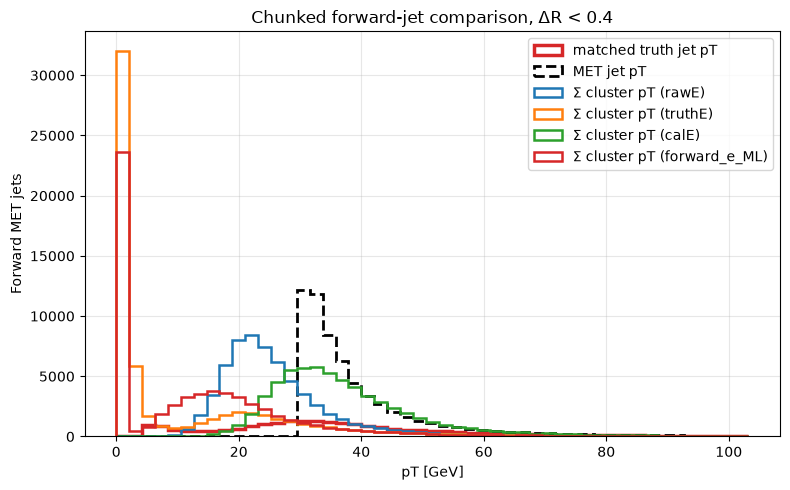

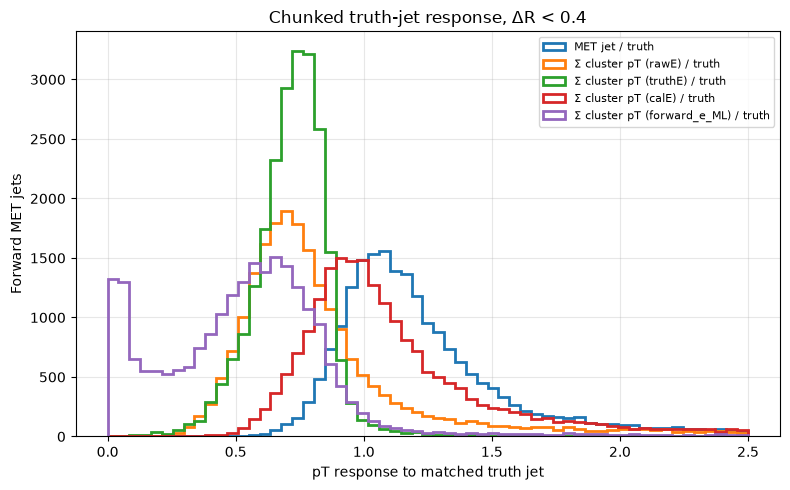

forward MET jets: 62297
truth matched jets: 23000
mean matched ΔR: 0.071
MET jet / truth: mean=1.686, median=1.191
Σ cluster pT (rawE) / truth: mean=1.106, median=0.770
Σ cluster pT (truthE) / truth: mean=0.726, median=0.729
Σ cluster pT (calE) / truth: mean=1.599, median=1.067
Σ cluster pT (forward_e_ML) / truth: mean=0.584, median=0.561


In [235]:
# Plot results produced by the chunked processing cell.
import matplotlib.pyplot as plt

chunked_pt_values = np.concatenate([
    forward_jet_pt_values_chunked,
    matched_truth_jet_pt_values_chunked,
    *(values for values in cluster_reco_pt_values_chunked.values()),
])
if chunked_pt_values.size == 0:
    raise ValueError("Run the chunked processing cell first, or no forward MET jets were found.")

chunked_pt_bins = np.linspace(
    0.0,
    max(50.0, 1.15 * np.nanpercentile(chunked_pt_values, 99.0)),
    50,
)

plt.figure(figsize=(8, 5))
plt.hist(
    matched_truth_jet_pt_values_chunked,
    bins=chunked_pt_bins,
    histtype="step",
    linewidth=2.5,
    color="tab:red",
    label="matched truth jet pT",
)
plt.hist(
    forward_jet_pt_values_chunked,
    bins=chunked_pt_bins,
    histtype="step",
    linewidth=2,
    linestyle="--",
    color="black",
    label="MET jet pT",
)
for scale_name, values in cluster_reco_pt_values_chunked.items():
    plt.hist(values, bins=chunked_pt_bins, histtype="step", linewidth=1.8, label=f"Σ cluster pT ({scale_name})")
plt.xlabel("pT [GeV]")
plt.ylabel("Forward MET jets")
plt.title(f"Chunked forward-jet comparison, ΔR < {JET_R}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

response_bins = np.linspace(0.0, 2.5, 60)
plt.figure(figsize=(8, 5))
for label, values in response_values_chunked.items():
    plt.hist(values, bins=response_bins, histtype="step", linewidth=2, label=label)
plt.xlabel("pT response to matched truth jet")
plt.ylabel("Forward MET jets")
plt.title(f"Chunked truth-jet response, ΔR < {JET_R}")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"forward MET jets: {forward_jet_pt_values_chunked.size}")
print(f"truth matched jets: {matched_truth_jet_pt_values_chunked.size}")
if matched_truth_jet_dr_values_chunked.size:
    print(f"mean matched ΔR: {np.mean(matched_truth_jet_dr_values_chunked):.3f}")
for label, values in response_values_chunked.items():
    if values.size:
        print(f"{label}: mean={np.mean(values):.3f}, median={np.median(values):.3f}")


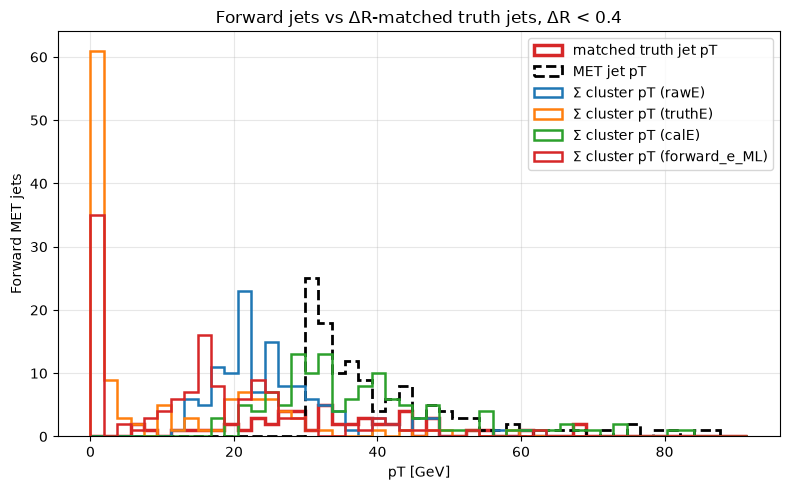

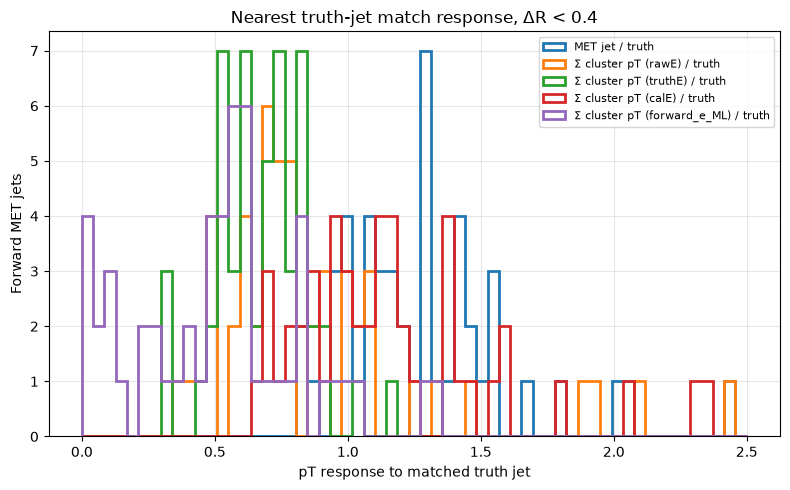

forward MET jets: 126
truth matched jets: 53
mean matched ΔR: 0.081
mean matched truth pT: 34.11 GeV
MET jet / truth: mean=1.615, median=1.300
Σ cluster pT (rawE) / truth: mean=1.021, median=0.775
Σ cluster pT (truthE) / truth: mean=0.678, median=0.698
Σ cluster pT (calE) / truth: mean=1.479, median=1.132
Σ cluster pT (forward_e_ML) / truth: mean=0.519, median=0.540


In [236]:
# Match each forward MET jet to the nearest truth jet within ΔR < 0.4,
# then compare truth pT to MET-jet pT and cluster-summed pT scales.
truth_jets = ak.zip({
    "idx": ak.local_index(arrays["tjet_pt"]),
    "pt": arrays["tjet_pt"] * GEV,
    "eta": arrays["tjet_eta"],
    "phi": arrays["tjet_phi"],
})

truth_pairs = ak.cartesian(
    {"jet": forward_met_jets, "truth": truth_jets},
    nested=True,
)
truth_match_dr = np.sqrt(
    (truth_pairs.truth.eta - truth_pairs.jet.eta) ** 2
    + delta_phi(truth_pairs.truth.phi, truth_pairs.jet.phi) ** 2
)
truth_pairs = ak.with_field(truth_pairs, truth_match_dr, "dr")
truth_matches = truth_pairs[truth_match_dr < JET_R]
nearest_truth_matches = ak.firsts(
    truth_matches[ak.argsort(truth_matches.dr, axis=-1)],
    axis=-1,
)

matched_truth_jet_pt = ak.fill_none(nearest_truth_matches.truth.pt, np.nan)
matched_truth_jet_dr = ak.fill_none(nearest_truth_matches.dr, np.nan)
matched_truth_jet_pt_values = finite_flatten(matched_truth_jet_pt)
matched_truth_jet_dr_values = finite_flatten(matched_truth_jet_dr)

comparison_pt_values = np.concatenate([
    forward_jet_pt_values,
    matched_truth_jet_pt_values,
    *(values for values in cluster_reco_pt_values.values()),
])
comparison_pt_bins = np.linspace(
    0.0,
    max(50.0, 1.15 * np.nanpercentile(comparison_pt_values, 99.0)),
    50,
)

plt.figure(figsize=(8, 5))
plt.hist(
    matched_truth_jet_pt_values,
    bins=comparison_pt_bins,
    histtype="step",
    linewidth=2.5,
    color="tab:red",
    label="matched truth jet pT",
)
plt.hist(
    forward_jet_pt_values,
    bins=comparison_pt_bins,
    histtype="step",
    linewidth=2,
    linestyle="--",
    color="black",
    label="MET jet pT",
)
for scale_name, values in cluster_reco_pt_values.items():
    plt.hist(
        values,
        bins=comparison_pt_bins,
        histtype="step",
        linewidth=1.8,
        label=f"Σ cluster pT ({scale_name})",
    )
plt.xlabel("pT [GeV]")
plt.ylabel("Forward MET jets")
plt.title(f"Forward jets vs ΔR-matched truth jets, ΔR < {JET_R}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

truth_pt_for_ratio = matched_truth_jet_pt
valid_truth_pt = np.isfinite(truth_pt_for_ratio) & (truth_pt_for_ratio > 0.0)
response_values = {
    "MET jet / truth": finite_flatten(ak.where(valid_truth_pt, forward_met_jets.pt / truth_pt_for_ratio, np.nan)),
}
for scale_name, cluster_pt in cluster_reco_pt_by_scale.items():
    response_values[f"Σ cluster pT ({scale_name}) / truth"] = finite_flatten(
        ak.where(valid_truth_pt, cluster_pt / truth_pt_for_ratio, np.nan)
    )

response_bins = np.linspace(0.0, 2.5, 60)
plt.figure(figsize=(8, 5))
for label, values in response_values.items():
    plt.hist(values, bins=response_bins, histtype="step", linewidth=2, label=label)
plt.xlabel("pT response to matched truth jet")
plt.ylabel("Forward MET jets")
plt.title(f"Nearest truth-jet match response, ΔR < {JET_R}")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"forward MET jets: {forward_jet_pt_values.size}")
print(f"truth matched jets: {matched_truth_jet_pt_values.size}")
if matched_truth_jet_dr_values.size:
    print(f"mean matched ΔR: {np.mean(matched_truth_jet_dr_values):.3f}")
    print(f"mean matched truth pT: {np.mean(matched_truth_jet_pt_values):.2f} GeV")
for label, values in response_values.items():
    if values.size:
        print(f"{label}: mean={np.mean(values):.3f}, median={np.median(values):.3f}")
